## Linear Regression Analysis

By Naomi Ortega

This notebook contains analysis of the factors influencing salary in AI roles using linear regression.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats

In [3]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')
data

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)


See if the annual salary is skewed

<Axes: xlabel='annual_salary_usd', ylabel='Count'>

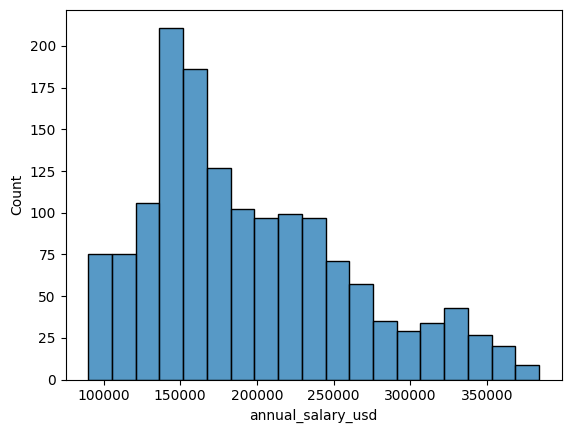

In [4]:
sns.histplot(data, x = 'annual_salary_usd')

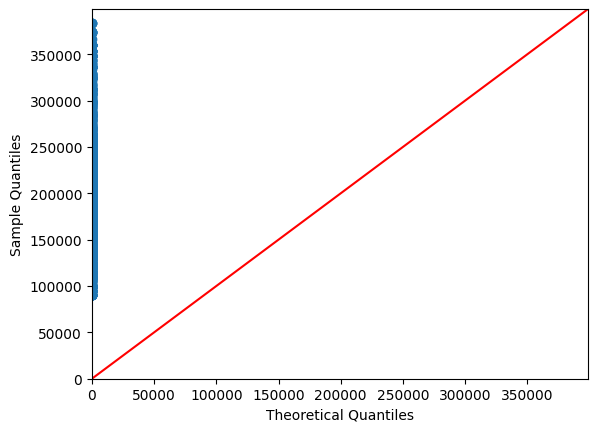

In [5]:
sm.qqplot(data['annual_salary_usd'], line = '45')
plt.show()


Since annual salary is skewed, we will use the log of annual salary.

In [6]:
data['log_salary'] = np.log(data['annual_salary_usd'])
data.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,log_salary
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),12.384219
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),12.019743
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),12.793859
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),11.989160
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),12.553202


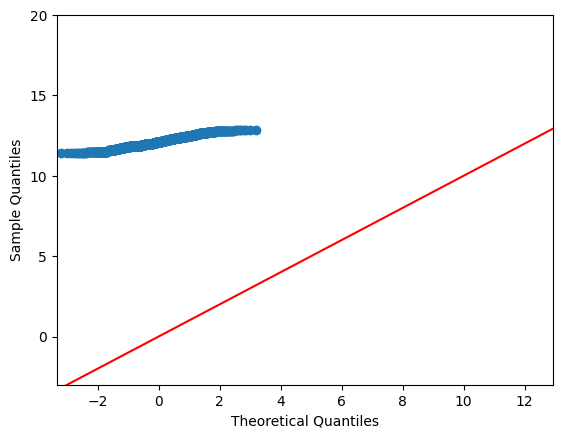

In [7]:
sm.qqplot(data['log_salary'], line = '45')
plt.ylim((-3,20))
plt.show()

In [8]:
print('Optimal lambda value from boxcox transformation:',stats.boxcox(data['annual_salary_usd'])[1])

Optimal lambda value from boxcox transformation: -0.12519558128627847


Questions to answer

1. Does years of experience have an effect on salary? Does increasing years of experience have the same effect across company size? Across industry? Across city?

## Linear Regression Model

We will use multivariate linear regression to see which variables have an effect on salary.  

### Variable selection

We want to select the variables that are relevant for predicting annual salary. We will use both forward and backward selection to assess the resulting variables.


First, before putting the data through the data selection algorithm, we create a new dataframe with the subsection of the variables to include only the ones that are possible to use as covariates in the linear regression model.
- Drop job_id
- We drop the response variable annual_salary_usd (the response variable is now contained in log_salary)
- Drop the salary related variables: ('salary_min_usd','salary_max_usd','ai_salary_premium_pct','is_senior','salary_tier')
- We drop is_senior because it is duplicative of the experience_level variable which creates dummy variables for each experience level in the regression model.
- drop required_skills because it is problematic for the selection algorithm.

In [9]:
data.head()
data.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'log_salary'],
      dtype='str')

In [10]:
subdata = data.drop(columns = ['required_skills','job_id', 'annual_salary_usd', 'is_senior', 'salary_min_usd','salary_max_usd','ai_salary_premium_pct','salary_tier'])
subdata.head()

,job_title,job_category,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_remote_friendly,is_llm_role,log_salary
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,Boston,USA,On-site,Startup (1-50),Finance,96,16.9,6.8,2026,3,0,1,12.384219
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,London,UK,Hybrid,Enterprise (5000+),Finance,82,11.6,6.2,2026,1,1,1,12.019743
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,98,42.7,7.7,2026,1,1,1,12.793859
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,Singapore,Singapore,Fully Remote,SME (51-500),Technology,88,6.7,9.5,2026,3,1,0,11.989160
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,85,17.3,8.9,2026,1,1,0,12.553202


In [11]:
def add(df, selected_columns, columns, criterion, response='y'):
    best_criterion = np.inf
    best_column = None
    for column in columns - selected_columns:
        new_columns = selected_columns.union({column})
        formula = f'{response} ~ {" + ".join(new_columns)}'
        current_criterion = criterion(formula, df)
        if current_criterion < best_criterion:
            best_criterion = current_criterion
            best_column = column
    return selected_columns.union({best_column}), best_criterion

In [12]:
def forward(df, criterion, response='y'):
    selected_columns = set()
    columns = set(df.columns.drop(response))
    best_criterion = np.inf
    while len(selected_columns) < len(columns):
        potential_columns, current_criterion = add(df, selected_columns, columns, criterion, response)
        if current_criterion > best_criterion:
            break
        else:
            selected_columns = potential_columns
            best_criterion = current_criterion
            print(f'Criterion: {best_criterion}')
    return selected_columns

In [13]:
bic_criterion = lambda formula, df: smf.ols(formula, subdata=df).fit().bic

Variable Selection using shrinkage methods

In [14]:
## hyperparameter selection for regularization parameter

from sklearn.model_selection import train_test_split
train, test = train_test_split(subdata, test_size = 0.25, random_state = 0)
train.shape, test.shape

def cv_error(alpha, l1wt, train, test):
    model = smf.ols(full_model_formula, data=train).\
                fit_regularized(method='elastic_net', alpha=alpha, L1_wt=l1wt)
    yhat_test = model.predict(test)
    error = np.sum((test['log_salary'] - yhat_test) ** 2)
    return error

In [15]:
full_model_formula = 'log_salary ~ ' + ' + '.join([c for c in subdata.columns if c != 'log_salary'])
full_model_formula

'log_salary ~ job_title + job_category + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + industry + demand_score + demand_growth_yoy_pct + benefits_score_10 + posting_year + posting_month + is_remote_friendly + is_llm_role'

In [16]:
l1wt = 1.0
alphas = np.linspace(1e-3, 0.5, 200)
cv_errors = np.zeros_like(alphas)

for (i, alpha) in enumerate(alphas):
    cv_errors[i] = cv_error(alpha, l1wt, train, test)

0 0.001
Optimal alpha: 0.001, CV Error: 6.017760449605665


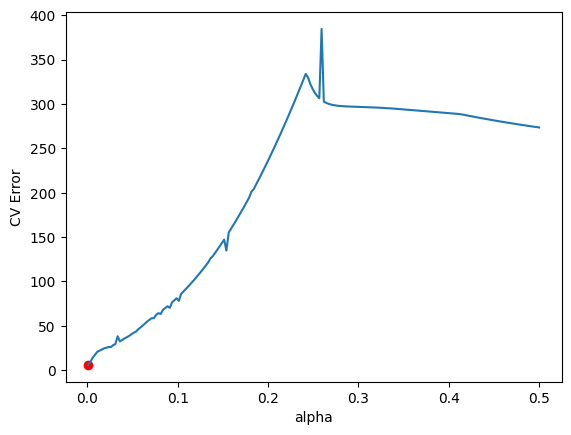

In [17]:
plt.plot(alphas, cv_errors)
print(np.argmin(cv_errors), alphas[np.argmin(cv_errors)])

print(f'Optimal alpha: {alphas[np.argmin(cv_errors)]}, CV Error: {cv_errors[np.argmin(cv_errors)]}')
plt.scatter(alphas[np.argmin(cv_errors)], cv_errors[np.argmin(cv_errors)], color='red')
plt.xlabel('alpha')
plt.ylabel('CV Error');

Using the optimal alpha obtained through cross-validation, apply the elastic net shrinkage method to obtain the useful covariates.

In [18]:
elastic_net = smf.ols(full_model_formula, data=subdata).\
                fit_regularized(method='elastic_net', alpha=alphas[np.argmin(cv_errors)], L1_wt=1.0)

Results:

Variables with 0 coefficients

In [19]:
print(elastic_net.params[elastic_net.params == 0])

job_title[T.AI Ethics Officer]         0.0
job_title[T.AI Product Manager]        0.0
job_title[T.AI Research Scientist]     0.0
job_title[T.AI Security Engineer]      0.0
job_title[T.Deep Learning Engineer]    0.0
job_title[T.Generative AI Engineer]    0.0
job_title[T.ML Engineer]               0.0
job_title[T.MLOps Engineer]            0.0
job_title[T.RAG Engineer]              0.0
job_title[T.Senior Data Scientist]     0.0
job_category[T.Architecture]           0.0
job_category[T.Business]               0.0
job_category[T.Data Engineering]       0.0
job_category[T.Data Science]           0.0
job_category[T.Infrastructure]         0.0
job_category[T.ML Operations]          0.0
job_category[T.Product]                0.0
job_category[T.Research]               0.0
job_category[T.Robotics]               0.0
job_category[T.Security]               0.0
education_required[T.Bachelor's]       0.0
education_required[T.Master's]         0.0
city[T.Austin]                         0.0
city[T.Bost

The shrinkage algorithm determined that many categories of job titles, job categories, industries, countries, and cities, did not have nonzero coefficients. Additionally, years_of_experience was determined to have a nonzero effect on salary. 

Variables with nonzero coefficients.

In [20]:
print(elastic_net.params[elastic_net.params != 0])

Intercept                                     12.049696
job_title[T.AI Business Analyst]              -0.326332
job_title[T.AI Compliance Manager]            -0.047912
job_title[T.AI Engineer]                      -0.166839
job_title[T.AI Infrastructure Eng]             0.008164
job_title[T.AI Solutions Architect]            0.239371
job_title[T.Computer Vision Engineer]          0.032114
job_title[T.Data Engineer (AI)]               -0.077462
job_title[T.Data Scientist]                   -0.130456
job_title[T.LLM Engineer]                      0.037083
job_title[T.Multimodal AI Engineer]            0.150043
job_title[T.NLP Engineer]                      0.068732
job_title[T.Prompt Engineer]                  -0.394640
job_title[T.Robotics Engineer (AI)]           -0.079313
job_title[T.Senior ML Engineer]                0.222530
job_category[T.Governance]                    -0.205254
experience_level[T.Lead (10+ yrs)]             0.465120
experience_level[T.Mid (3-5 yrs)]              0

The variables with nonzero coefficients (in the case of categorical variables, at least 1 of the categories has a nonzero coefficient) from elastic net are: job_title, job_category, experience_level, education_required, city, country, company_size, demand_score, demand_growth_yoy_pct, benefits_score_10, posting_year, posting month, and is_llm_role.

Additionally, posting_year and posting_month both have very small values close to 0, -0.000010 and -0.000223 respectively, and do not make sense independent of each other. 

-------------------------
cut out below? tried using forward selection but didnt work- only tried bic criteria 

We attempted to use forward selection for variable selection, but using the bic_criterion, the criterion began at -77,168 and did not finish running after 8 minutes.

In [25]:
subdata.country.value_counts().sort_index()

country
Australia       78
Canada          85
China           87
France          66
Germany         81
Global          82
India           57
Japan           76
Netherlands     74
Singapore       71
Switzerland     76
UAE             62
UK              90
USA            515
Name: count, dtype: int64

------------------------------------

## Final model: significant variables

As a result of using variable selection with elastic fit, to result in variables that have an effect on annual salary of AI job roles, our final model for our main analysis using multivariate linear regression includes the following variables:
(in the case of categorical variables, at least 1 of the categories has a nonzero coefficient) from elastic fit are: 
* `job_title`- Role title
* `job_category` - Role category: (Data Science, AI Engineering, etc.)
* `experience_level` - Entry, Mid, Senior, or Lead
* `education_required` - Minimum required education level
* `city` - City location of job
* `country` - Country location of job
* `company_size` - Startup, SME, Mid-size, Enterprise, Big Tech
* `demand_score` - Market demand score 0-100
* `demand_growth_yoy_pct` - Year-over-year demand growth percentage
* `benefits_score_10` - Benefits package quality score
* `is_llm_role` - binary variable 


But we know that city and country are not independent, so we will only use city or country in the model.

## Fitting the linear model

In [22]:
final_vars = ['job_title','job_category','experience_level','education_required','country','company_size','demand_score','demand_growth_yoy_pct','benefits_score_10','is_llm_role']
final_formula = 'log_salary ~ ' + ' + '.join(final_vars)
final_model = smf.ols(final_formula, data = subdata).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     204.3
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        17:34:38   Log-Likelihood:                 1077.5
No. Observations:                1500   AIC:                            -2053.
Df Residuals:                    1449   BIC:                            -1782.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [28]:
final_vars = ['job_title','job_category','experience_level','education_required','country','company_size','demand_score','demand_growth_yoy_pct','benefits_score_10','is_llm_role']
formula = "log_salary ~ job_title + job_category + is_llm_role*experience_level + education_required + country + company_size + demand_score + demand_growth_yoy_pct + benefits_score_10"

final_model = smf.ols(formula, data = subdata).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     192.9
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        18:06:39   Log-Likelihood:                 1079.5
No. Observations:                1500   AIC:                            -2051.
Df Residuals:                    1446   BIC:                            -1764.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

None of the interaction terms are significant. The role being an LLM role does not have a significant effect on the difference in salary between entry level positions and any other experience level.

## Interpretations:


In [ ]:
#visualizations